In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import pandas as pd
df = pd.DataFrame({
"Hours": [1,2,3,4,5,6,7,8,9,10],
"Score": [35,40,50,55,60,66,70,78,85,90]
})
print(df.head())

   Hours  Score
0      1     35
1      2     40
2      3     50
3      4     55
4      5     60


In [ ]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isna().sum())

   Hours  Score
0      1     35
1      2     40
2      3     50
3      4     55
4      5     60
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hours   10 non-null     int64
 1   Score   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None
          Hours      Score
count  10.00000  10.000000
mean    5.50000  62.900000
std     3.02765  18.411651
min     1.00000  35.000000
25%     3.25000  51.250000
50%     5.50000  63.000000
75%     7.75000  76.000000
max    10.00000  90.000000
Hours    0
Score    0
dtype: int64


In [ ]:
df["Hours"] = df["Hours"].fillna(df["Hours"].median())
df["Score"] = df["Score"].fillna(df["Score"].median())

In [ ]:
X = df[["Hours"]]
y = df["Score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse, "R2:", r2)

MSE: 3.4962098692033203 R2: 0.9930939064312033


In [ ]:
result = X_test.copy()
result["Actual"] = y_test.values
result["Predicted"] = y_pred.round(2)
print(result)

   Hours  Actual  Predicted
8      9      85       83.7
1      2      40       42.3


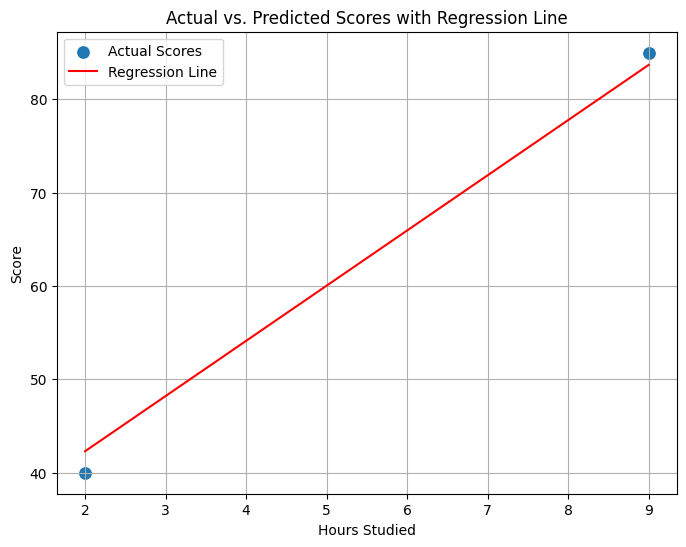

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test['Hours'], y=y_test, label='Actual Scores', s=100)
sns.lineplot(x=X_test['Hours'], y=y_pred, color='red', label='Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Actual vs. Predicted Scores with Regression Line')
plt.legend()
plt.grid(True)
plt.show()